Informações sobre os dados:
Dimensões: (256, 256, 256)

Estatísticas da velocidade:
vx - min: -9.929, max: 9.124, mean: -0.000
vy - min: -11.806, max: 12.324, mean: 0.000
vz - min: -12.218, max: 11.925, mean: -0.000


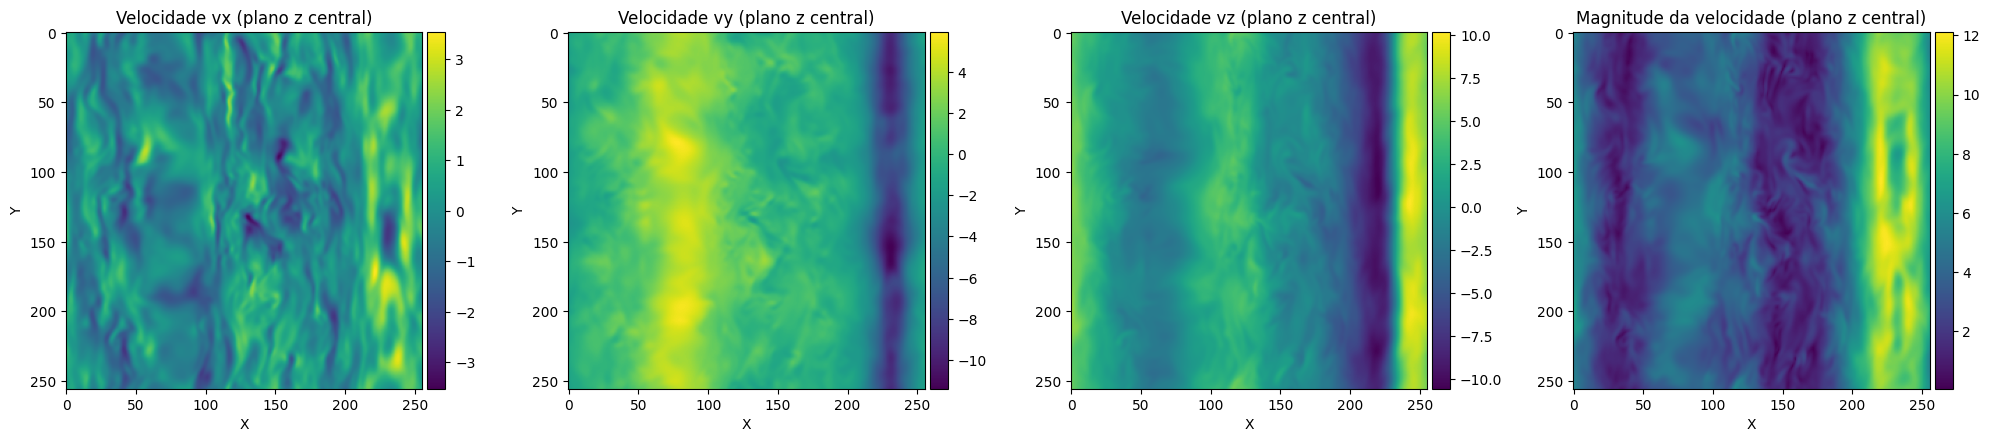


Análise estatística adicional:
Energia cinética total: 7.172
Vorticidade média: 0.190


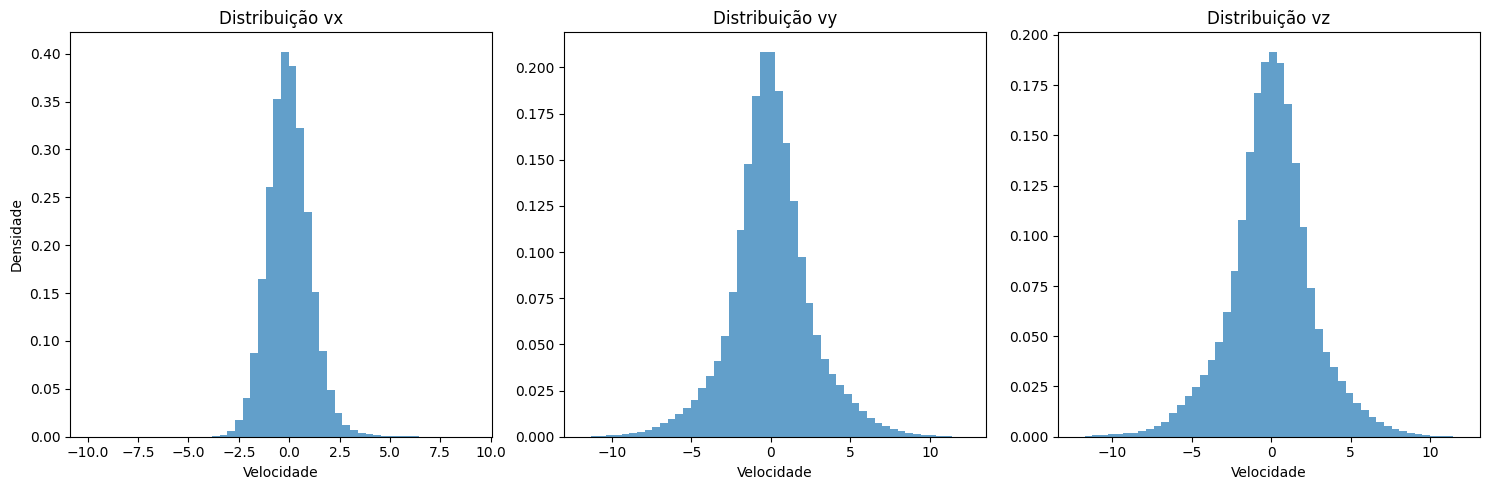


Dados salvos em: /home/romulo/Documentos/lpips-env/data/turb_data.npz


In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Carregar o arquivo HDF5
file_path = '/home/romulo/Documentos/lpips-env/data/velo_227.h5'
f = h5py.File(file_path, 'r')

# Carregar os dados de velocidade
vx = f['PS3D/vx'][()]
vy = f['PS3D/vy'][()]
vz = f['PS3D/vz'][()]

print("Informações sobre os dados:")
print(f"Dimensões: {vx.shape}")
print(f"\nEstatísticas da velocidade:")
print(f"vx - min: {vx.min():.3f}, max: {vx.max():.3f}, mean: {vx.mean():.3f}")
print(f"vy - min: {vy.min():.3f}, max: {vy.max():.3f}, mean: {vy.mean():.3f}")
print(f"vz - min: {vz.min():.3f}, max: {vz.max():.3f}, mean: {vz.mean():.3f}")

# Calcular a magnitude da velocidade
v_mag = np.sqrt(vx**2 + vy**2 + vz**2)

# Função para criar plots com colorbar adequada
def plot_with_colorbar(ax, data, title):
    im = ax.imshow(data, cmap='viridis')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

# Visualizar um plano central de cada componente
z_mid = vx.shape[2] // 2  # Plano central em z

plt.figure(figsize=(20, 5))

# Componente x da velocidade
ax1 = plt.subplot(141)
plot_with_colorbar(ax1, vx[:,:,z_mid], 'Velocidade vx (plano z central)')

# Componente y da velocidade
ax2 = plt.subplot(142)
plot_with_colorbar(ax2, vy[:,:,z_mid], 'Velocidade vy (plano z central)')

# Componente z da velocidade
ax3 = plt.subplot(143)
plot_with_colorbar(ax3, vz[:,:,z_mid], 'Velocidade vz (plano z central)')

# Magnitude da velocidade
ax4 = plt.subplot(144)
plot_with_colorbar(ax4, v_mag[:,:,z_mid], 'Magnitude da velocidade (plano z central)')

plt.tight_layout()
plt.show()

# Análise estatística adicional
print("\nAnálise estatística adicional:")
print(f"Energia cinética total: {0.5 * np.mean(v_mag**2):.3f}")
print(f"Vorticidade média: {np.mean(np.abs(np.gradient(vy)[0] - np.gradient(vx)[1])):.3f}")

# Histograma das componentes de velocidade
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.hist(vx.flatten(), bins=50, density=True, alpha=0.7)
plt.title('Distribuição vx')
plt.xlabel('Velocidade')
plt.ylabel('Densidade')

plt.subplot(132)
plt.hist(vy.flatten(), bins=50, density=True, alpha=0.7)
plt.title('Distribuição vy')
plt.xlabel('Velocidade')

plt.subplot(133)
plt.hist(vz.flatten(), bins=50, density=True, alpha=0.7)
plt.title('Distribuição vz')
plt.xlabel('Velocidade')

plt.tight_layout()
plt.show()

# Salvar os dados processados em formato numpy
output_path = '/home/romulo/Documentos/lpips-env/data/turb_data.npz'
np.savez(output_path, 
         vx=vx, 
         vy=vy, 
         vz=vz, 
         v_mag=v_mag)

print(f"\nDados salvos em: {output_path}")

# Fechar o arquivo
f.close()

Shape original dos dados: (256, 256, 256)

Shape dos dados reorganizados: (256, 256, 256, 3)
Interpretação: (passos de tempo, altura, largura, componentes de velocidade)


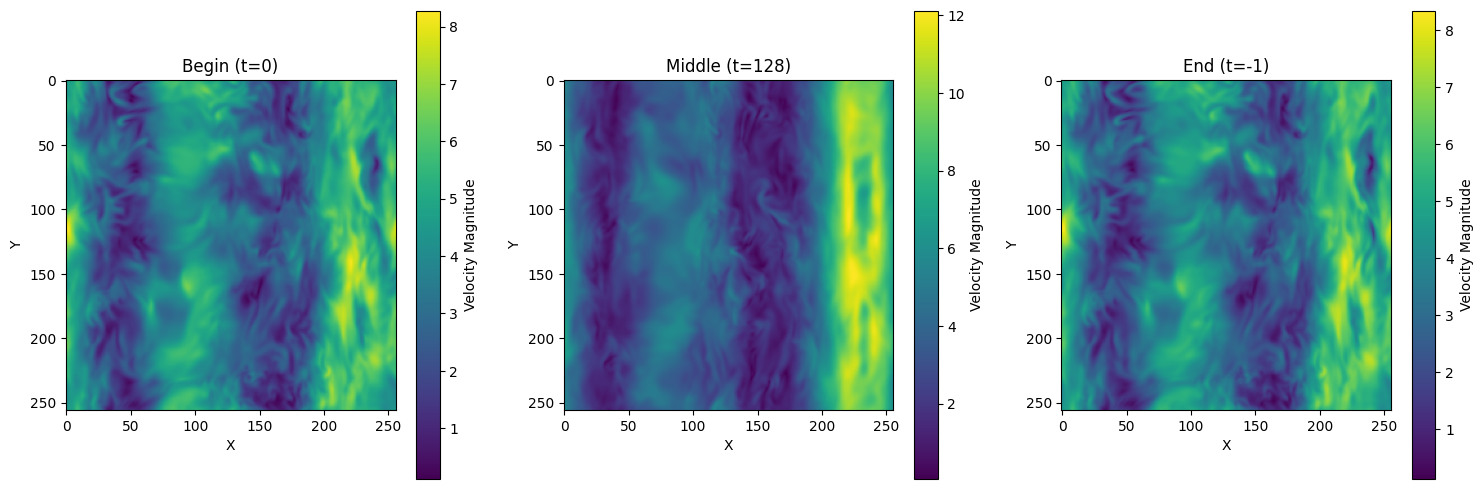


Dados salvos em: /home/romulo/Documentos/lpips-env/data/turb_time_series.npy
Shape dos dados salvos: (256, 256, 256, 3)

Agora você pode usar estes dados com seu código PIV, onde:
- Primeira dimensão (256): passos de tempo
- Segunda e terceira dimensões (256, 256): campo espacial 2D
- Quarta dimensão (3): componentes da velocidade (vx, vy, vz)


In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Carregar o arquivo HDF5
file_path = '/home/romulo/Documentos/lpips-env/data/velo_227.h5'
f = h5py.File(file_path, 'r')

# Carregar os dados de velocidade
vx = f['PS3D/vx'][()]
vy = f['PS3D/vy'][()]
vz = f['PS3D/vz'][()]

print("Shape original dos dados:", vx.shape)

# Vamos reorganizar os dados para criar uma série temporal
# Usando a terceira dimensão (z) como "tempo"
n_time_steps = vx.shape[2]  # 256 passos de "tempo"
spatial_dims = (vx.shape[0], vx.shape[1])  # (256, 256) dimensões espaciais

# Reorganizar os dados para formato de série temporal
time_series_data = np.zeros((n_time_steps, spatial_dims[0], spatial_dims[1], 3))
time_series_data[:, :, :, 0] = np.transpose(vx, (2, 0, 1))  # Componente x
time_series_data[:, :, :, 1] = np.transpose(vy, (2, 0, 1))  # Componente y
time_series_data[:, :, :, 2] = np.transpose(vz, (2, 0, 1))  # Componente z

print("\nShape dos dados reorganizados:", time_series_data.shape)
print("Interpretação: (passos de tempo, altura, largura, componentes de velocidade)")

# Visualizar a evolução temporal
plt.figure(figsize=(15, 5))

# Plotar três "instantes de tempo" diferentes
times = [0, n_time_steps//2, -1]
titles = ['Begin', 'Middle', 'End']

for i, (t, title) in enumerate(zip(times, titles)):
    plt.subplot(1, 3, i+1)
    # Plotar a magnitude da velocidade para cada instante
    magnitude = np.sqrt(np.sum(time_series_data[t, :, :, :]**2, axis=-1))
    plt.imshow(magnitude, cmap='viridis')
    plt.colorbar(label='Velocity Magnitude')
    plt.title(f'{title} (t={t})')
    plt.xlabel('X')
    plt.ylabel('Y')

plt.tight_layout()
plt.show()

# Salvar os dados no formato adequado para o PIV
output_path = '/home/romulo/Documentos/lpips-env/data/turb_time_series.npy'
np.save(output_path, time_series_data)

print(f"\nDados salvos em: {output_path}")
print("Shape dos dados salvos:", time_series_data.shape)
print("\nAgora você pode usar estes dados com seu código PIV, onde:")
print("- Primeira dimensão (256): passos de tempo")
print("- Segunda e terceira dimensões (256, 256): campo espacial 2D")
print("- Quarta dimensão (3): componentes da velocidade (vx, vy, vz)")

f.close()

Dados processados salvos em: /home/romulo/Documentos/lpips-env/data/turb_vy.npy
Shape dos dados: (256, 256, 256)


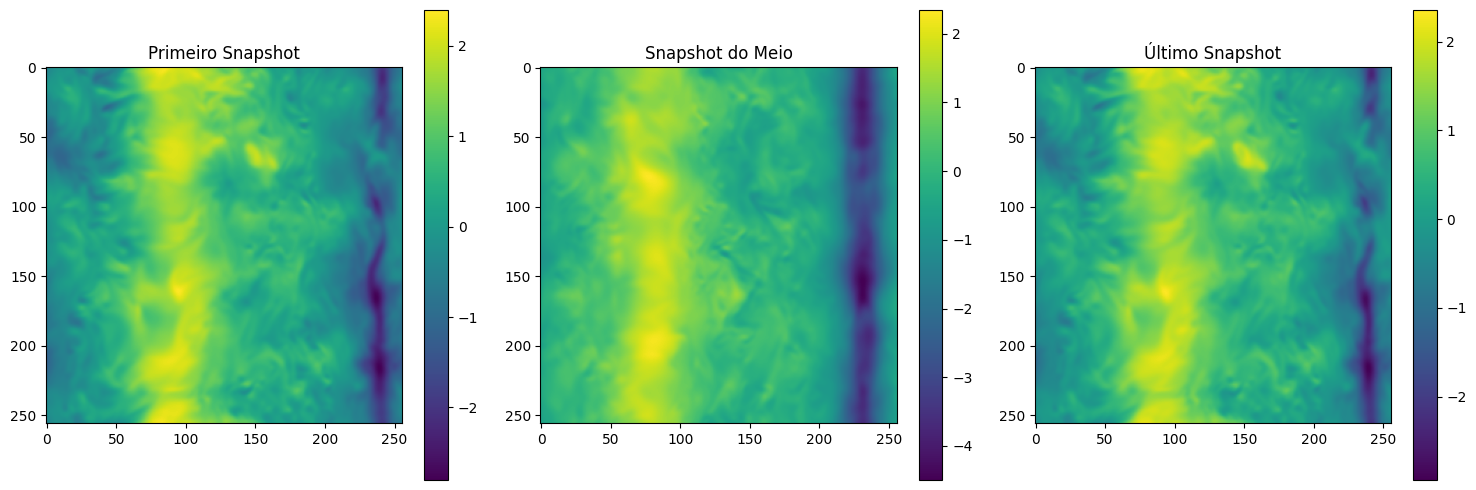


Agora você pode usar este arquivo com o código PIV modificando a linha do caminho do arquivo para:
npy_file_path = r'/home/romulo/Documentos/lpips-env/data/turb_vy.npy'


In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Função para processar os dados de turbulência para uso no PIV
def process_turb_data(file_path, component='vy', slice_size=50):
    """
    Processa os dados de turbulência para uso no PIV.
    
    Args:
        file_path: caminho para o arquivo .h5
        component: componente de velocidade a usar ('vx', 'vy' ou 'vz')
        slice_size: número de slices temporais a usar
    """
    # Carregar dados
    with h5py.File(file_path, 'r') as f:
        # Selecionar a componente de velocidade
        data = f[f'PS3D/{component}'][()]
    
    # Reorganizar os dados para formato temporal
    # Usar z como dimensão temporal
    data = np.transpose(data, (2, 0, 1))  # (tempo, x, y)
    
    # Selecionar um subconjunto dos dados para reduzir a dimensionalidade
    if slice_size:
        data = data[:slice_size]
    
    # Normalizar os dados
    data = (data - np.mean(data)) / np.std(data)
    
    # Salvar em formato .npy para uso com o PIV
    output_path = f'/home/romulo/Documentos/lpips-env/data/turb_{component}.npy'
    np.save(output_path, data)
    
    print(f"Dados processados salvos em: {output_path}")
    print(f"Shape dos dados: {data.shape}")
    
    # Visualizar alguns aspectos dos dados
    plt.figure(figsize=(15, 5))
    
    # Primeiro snapshot
    plt.subplot(131)
    plt.imshow(data[0], cmap='viridis')
    plt.colorbar()
    plt.title('Primeiro Snapshot')
    
    # Snapshot do meio
    plt.subplot(132)
    plt.imshow(data[len(data)//2], cmap='viridis')
    plt.colorbar()
    plt.title('Snapshot do Meio')
    
    # Último snapshot
    plt.subplot(133)
    plt.imshow(data[-1], cmap='viridis')
    plt.colorbar()
    plt.title('Último Snapshot')
    
    plt.tight_layout()
    plt.show()
    
    return output_path, data.shape

# Processar os dados
file_path = '/home/romulo/Documentos/lpips-env/data/velo_227.h5'
output_path, data_shape = process_turb_data(file_path, component='vy', slice_size=280)

print("\nAgora você pode usar este arquivo com o código PIV modificando a linha do caminho do arquivo para:")
print(f"npy_file_path = r'{output_path}'")

Shape dos dados combinados (x, y, tempo): (256, 256, 1024)


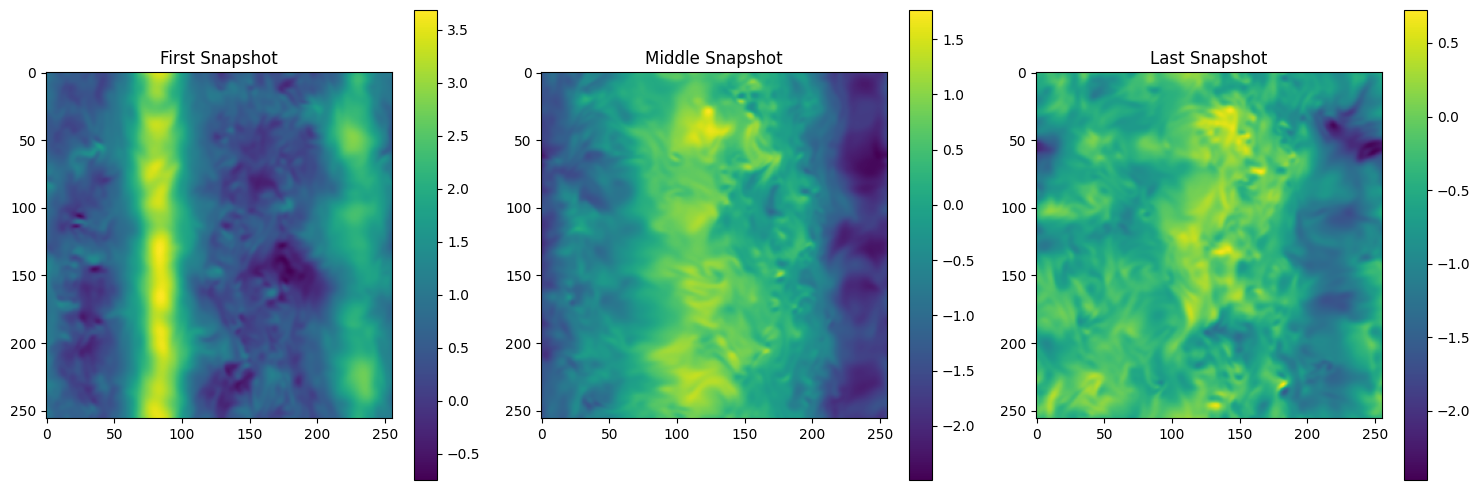

Dados processados salvos em: /home/romulo/Documentos/lpips-env/data/turb_vy_combined.npy

Agora você pode usar este arquivo com o código PIV modificando a linha do caminho do arquivo para:
npy_file_path = r'/home/romulo/Documentos/lpips-env/data/turb_vy_combined.npy'


In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def load_and_process_h5_files(file_paths, component='vy'):
    """
    Carrega e concatena múltiplos arquivos .h5, processando-os para uso no PIV.
    
    Args:
        file_paths: lista com caminhos dos arquivos .h5
        component: componente de velocidade a usar ('vx', 'vy' ou 'vz')
    """
    # Lista para armazenar os dados de cada arquivo
    all_data = []
    
    # Carregar dados de cada arquivo
    for file_path in sorted(file_paths):
        with h5py.File(file_path, 'r') as f:
            data = f[f'PS3D/{component}'][()]
            # Manter formato (x, y, tempo)
            all_data.append(data)
    
    # Concatenar os dados no eixo temporal (axis=2)
    combined_data = np.concatenate(all_data, axis=2)
    
    # Normalizar os dados
    combined_data = (combined_data - np.mean(combined_data)) / np.std(combined_data)
    
    print(f"Shape dos dados combinados (x, y, tempo): {combined_data.shape}")
    
    # Visualizar alguns aspectos dos dados
    plt.figure(figsize=(15, 5))
    
    # Primeiro snapshot
    plt.subplot(131)
    plt.imshow(combined_data[:, :, 0], cmap='viridis')
    plt.colorbar()
    plt.title('First Snapshot')
    
    # Snapshot do meio
    mid_idx = combined_data.shape[2] // 2
    plt.subplot(132)
    plt.imshow(combined_data[:, :, mid_idx], cmap='viridis')
    plt.colorbar()
    plt.title('Middle Snapshot')
    
    # Último snapshot
    plt.subplot(133)
    plt.imshow(combined_data[:, :, -1], cmap='viridis')
    plt.colorbar()
    plt.title('Last Snapshot')
    
    plt.tight_layout()
    plt.savefig(f'/home/romulo/Documentos/lpips-env/data/turb_{component}_combined.png')
    plt.show()
   
    
    # Sobrescrever o arquivo existente
    output_path = f'/home/romulo/Documentos/lpips-env/data/turb_{component}_combined.npy'
    np.save(output_path, combined_data)
    print(f"Dados processados salvos em: {output_path}")
    
    return output_path, combined_data.shape

# Lista de arquivos para processar
file_paths = [
    '/home/romulo/Documentos/lpips-env/data/velo_226.h5',
    '/home/romulo/Documentos/lpips-env/data/velo_227.h5',
    '/home/romulo/Documentos/lpips-env/data/velo_228.h5',
    '/home/romulo/Documentos/lpips-env/data/velo_229.h5'
]

# Processar os dados
output_path, data_shape = load_and_process_h5_files(file_paths, component='vy')

print("\nAgora você pode usar este arquivo com o código PIV modificando a linha do caminho do arquivo para:")
print(f"npy_file_path = r'{output_path}'")